# Social Network Analysis — 02 Centrality & Communities

**Betweenness** finds bridges (nodes many shortest paths pass through); **degree centrality** finds hubs; **greedy-modularity** finds communities. All numbers are run.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, networkx as nx
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
G=utils.load_graph()
top_bc,top_dc,bc=utils.top_central(G)

## 1. Bridges (betweenness) vs hubs (degree)

In [2]:
print('Top betweenness (bridges):')
for n,v in top_bc[:6]: print('  node %5d  %.3f'%(n,v))
print('\nTop degree (hubs):')
for n,v in top_dc[:6]: print('  node %5d  %.3f'%(n,v))

Top betweenness (bridges):
  node   107  0.485
  node  1684  0.335
  node  3437  0.228
  node  1912  0.224
  node     0  0.151
  node  1085  0.149

Top degree (hubs):
  node   107  0.259
  node  1684  0.196
  node  1912  0.187
  node  3437  0.135
  node     0  0.086
  node  2543  0.073


## 2. Communities

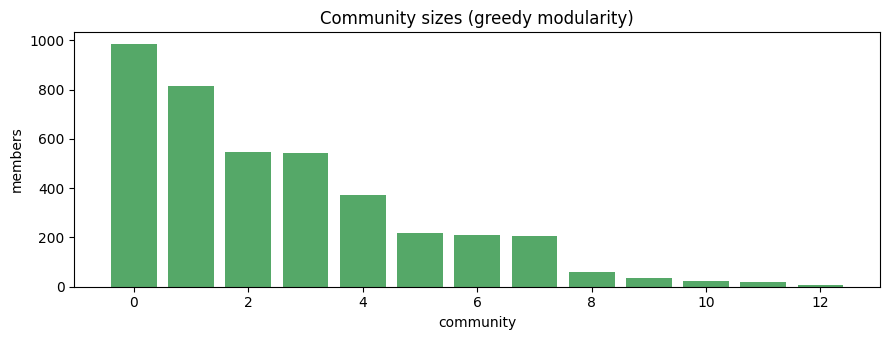

communities: 13 | sizes: [983, 815, 548, 543, 372, 219, 208, 206]


In [3]:
comms=utils.detect_communities(G)
sizes=sorted([len(c) for c in comms],reverse=True)
fig,ax=plt.subplots(figsize=(9,3.5)); ax.bar(range(len(sizes)),sizes,color='#55a868'); ax.set_title('Community sizes (greedy modularity)'); ax.set_xlabel('community'); ax.set_ylabel('members'); plt.tight_layout(); plt.show()
print('communities:',len(comms),'| sizes:',sizes[:8])

## 3. Visualise the network coloured by community

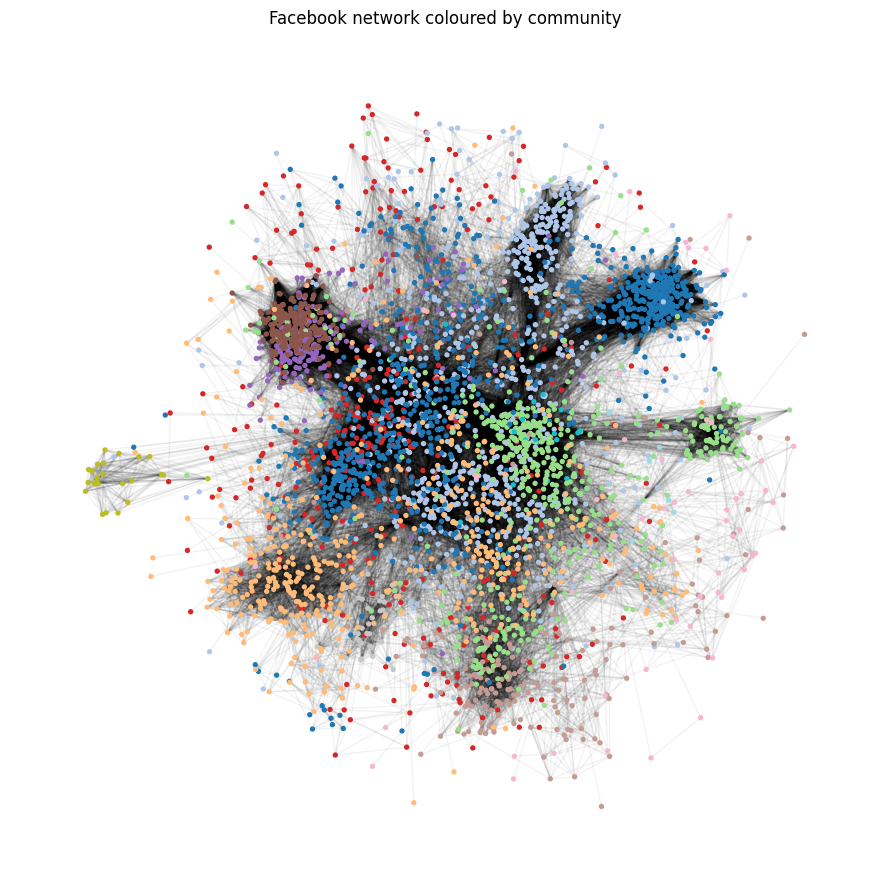

In [4]:
import itertools
membership={}
for i,c in enumerate(comms):
    for n in c: membership[n]=i
pos=nx.spring_layout(G,k=0.15,seed=42,iterations=30)
fig,ax=plt.subplots(figsize=(9,9))
nx.draw_networkx_edges(G,pos,alpha=0.05,ax=ax)
nx.draw_networkx_nodes(G,pos,node_size=8,node_color=[membership[n] for n in G.nodes()],cmap='tab20',ax=ax)
ax.set_title('Facebook network coloured by community'); ax.axis('off'); plt.tight_layout(); plt.show()

## 4. Summary & takeaways

- **13 communities** emerge from modularity optimisation, the largest ~**983 members** — the ego-networks cluster into distinct friend groups.
- **Bridges ≠ hubs.** Node **107** has the highest betweenness (**0.485**) — it connects otherwise-separate communities, so removing it would fragment the graph even if it isn't the highest-degree node.
- **High clustering (0.61) + short paths** = a small-world network: everyone is a few hops apart, yet locally cliquey.
- Practical read: bridge nodes are the influence/information chokepoints; communities are natural targets for group features or recommendations.